In [7]:

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests
from IPython.display import display
import numpy as np
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/behaviour_detection.csv')
df1['condition'] = 'Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/behaviour_detection.csv')
df2["condition"] = np.where(df2["track_id"] == 0, "Starved (F-S)", "Fed (F-S)")

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/behaviour_detection.csv')
df3['condition'] = 'Starved-Starved'

df = pd.concat([df1, df2, df3], ignore_index=True)  


order = [
    'Fed-Fed', 'Fed (F-S)', 'Starved (F-S)', 'Starved-Starved'
]

palette = {
    'Fed-Fed': '#4C72B0',
    'Starved (F-S)': '#F3D00E',
    'Fed (F-S)': '#0B5D2A',
    'Starved-Starved': '#C44E52',
}



/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_1749/491530434.py:21: DtypeWarning: Columns (97,100) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/behaviour_detection.csv')


/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


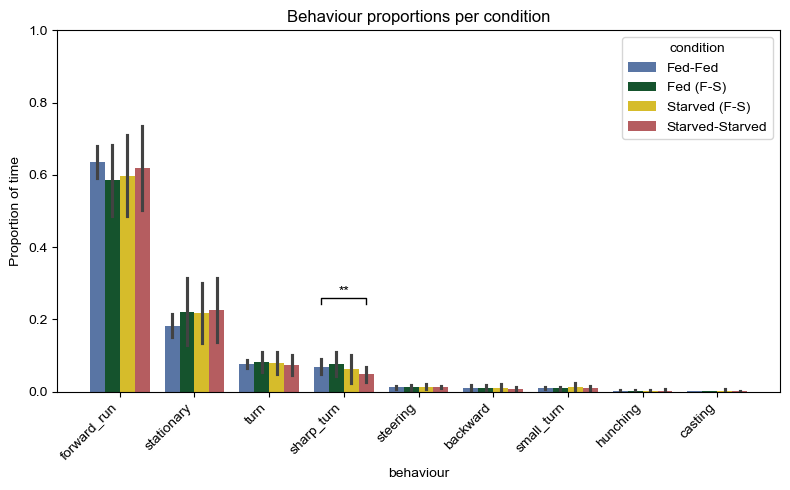

Omnibus tests


,behaviour,test,H,p,stars
3,sharp_turn,Kruskal-Wallis,17.297884,0.000614,***
0,forward_run,Kruskal-Wallis,5.094939,0.164976,ns
1,stationary,Kruskal-Wallis,4.736728,0.192122,ns
5,backward,Kruskal-Wallis,4.535627,0.209134,ns
2,turn,Kruskal-Wallis,4.017427,0.259588,ns
7,hunching,Kruskal-Wallis,3.458001,0.326250,ns
8,casting,Kruskal-Wallis,3.411643,0.332404,ns
6,small_turn,Kruskal-Wallis,2.452038,0.484021,ns
4,steering,Kruskal-Wallis,2.000591,0.572284,ns


Pairwise tests for behaviours with significant omnibus p < 0.05, Holm-corrected within behaviour


,behaviour,condition_a,condition_b,comparison,test,n,stat,p_raw,p_fdr,stars
21,backward,Fed-Fed,Starved-Starved,Fed-Fed vs Starved-Starved,Mann-Whitney U,27 vs 27,486.0,0.036323,0.108968,ns
22,backward,Starved-Starved,Starved (F-S),Starved-Starved vs Starved (F-S),Mann-Whitney U,27 vs 26,310.0,0.470991,0.844653,ns
20,backward,Fed-Fed,Fed (F-S),Fed-Fed vs Fed (F-S),Mann-Whitney U,27 vs 26,375.5,0.669367,0.860615,ns
23,backward,Fed (F-S),Starved (F-S),Fed (F-S) vs Starved (F-S),Wilcoxon signed-rank,26 pairs,145.0,0.637733,0.903151,ns
33,casting,Fed-Fed,Starved-Starved,Fed-Fed vs Starved-Starved,Mann-Whitney U,27 vs 27,477.0,0.052600,0.118351,ns
35,casting,Fed (F-S),Starved (F-S),Fed (F-S) vs Starved (F-S),Wilcoxon signed-rank,26 pairs,133.0,0.427339,0.769210,ns
34,casting,Starved-Starved,Starved (F-S),Starved-Starved vs Starved (F-S),Mann-Whitney U,27 vs 26,326.0,0.661785,0.850866,ns
32,casting,Fed-Fed,Fed (F-S),Fed-Fed vs Fed (F-S),Mann-Whitney U,27 vs 26,348.0,0.964517,0.964517,ns
0,forward_run,Fed-Fed,Fed (F-S),Fed-Fed vs Fed (F-S),Mann-Whitney U,27 vs 26,472.0,0.032038,0.288341,ns
3,forward_run,Fed (F-S),Starved (F-S),Fed (F-S) vs Starved (F-S),Wilcoxon signed-rank,26 pairs,127.0,0.226959,0.533138,ns


In [8]:
# Proportion of time, excluding digging, with stats and plot significance labels

prop_df = df[df["behaviour"].astype(str).str.lower() != "digging"].copy()
# prop_df = df.copy()

# The comparisons we actually want. Fed (F-S) vs Starved (F-S) are the two larvae
# on the SAME plate, so that one is paired; the rest are between different plates.
COMPARISONS = [
    ('Fed-Fed',         'Fed (F-S)',       'unpaired'),
    ('Fed-Fed',         'Starved-Starved', 'unpaired'),
    ('Starved-Starved', 'Starved (F-S)',   'unpaired'),
    ('Fed (F-S)',       'Starved (F-S)',   'paired'),
]

# Total non-digging frames per recording and condition.
total_frames = (
    prop_df.groupby(["file", "condition", 'track_id'])
    .size()
    .reset_index(name="total_frames")
)

# Frames per behaviour per recording and condition.
behaviour_frames = (
    prop_df.groupby(["file", "condition", "behaviour", 'track_id'])
    .size()
    .reset_index(name="n_frames")
)

behaviour_order = (
    behaviour_frames.groupby("behaviour")["n_frames"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

recordings = total_frames[["file", "condition", 'track_id']].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

behaviour_prop = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(behaviour_frames, on=["file", "condition", "behaviour", 'track_id'], how="left")
    .merge(total_frames, on=["file", "condition", 'track_id'], how="left")
)
behaviour_prop["n_frames"] = behaviour_prop["n_frames"].fillna(0)
behaviour_prop = behaviour_prop[behaviour_prop["total_frames"] > 0].copy()
behaviour_prop["proportion"] = behaviour_prop["n_frames"] / behaviour_prop["total_frames"]

# Each larva now has its own proportion. Collapse the two larvae on Fed-Fed and
# Starved-Starved plates back to one value per plate, so those groups do not
# contribute two non-independent points. F-S rows pass through unchanged, because
# there each condition is already a single larva.
behaviour_prop = (
    behaviour_prop
    .groupby(["file", "condition", "behaviour"], as_index=False)["proportion"]
    .mean()
)

# Order by the final plotted value: overall mean proportion, highest to lowest.
behaviour_order = (
    behaviour_prop.groupby("behaviour")["proportion"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)


def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

proportion_omnibus_rows = []
proportion_pairwise_rows = []

for behaviour in behaviour_order:
    behaviour_data = behaviour_prop[behaviour_prop["behaviour"] == behaviour]
    groups = [
        behaviour_data.loc[behaviour_data["condition"] == condition, "proportion"].dropna()
        for condition in order
    ]

    if all(len(group) > 0 for group in groups):
        h_stat, p_value = kruskal(*groups)
    else:
        h_stat, p_value = np.nan, np.nan

    proportion_omnibus_rows.append({
        "behaviour": behaviour,
        "test": "Kruskal-Wallis",
        "H": h_stat,
        "p": p_value,
        "stars": p_to_stars(p_value),
    })

    if True:                                   # planned comparisons, no omnibus gate
        comparisons = []
        raw_p_values = []

        for condition_a, condition_b, kind in COMPARISONS:
            if kind == "paired":
                test_name = "Wilcoxon signed-rank"
                paired = behaviour_data[
                    behaviour_data["condition"].isin([condition_a, condition_b])
                ].pivot_table(index="file", columns="condition", values="proportion")

                if {condition_a, condition_b}.issubset(paired.columns):
                    paired = paired.dropna(subset=[condition_a, condition_b])
                else:
                    paired = paired.iloc[0:0]

                try:
                    stat, pair_p = wilcoxon(paired[condition_a], paired[condition_b])
                except (ValueError, KeyError):
                    # raised when there are no pairs, or every difference is zero
                    stat, pair_p = np.nan, np.nan
                n_desc = f"{len(paired)} pairs"
            else:
                test_name = "Mann-Whitney U"
                values_a = behaviour_data.loc[
                    behaviour_data["condition"] == condition_a,
                    "proportion"
                ].dropna()
                values_b = behaviour_data.loc[
                    behaviour_data["condition"] == condition_b,
                    "proportion"
                ].dropna()

                if len(values_a) > 0 and len(values_b) > 0:
                    stat, pair_p = mannwhitneyu(values_a, values_b, alternative="two-sided")
                else:
                    stat, pair_p = np.nan, np.nan
                n_desc = f"{len(values_a)} vs {len(values_b)}"

            comparisons.append((condition_a, condition_b, test_name, stat, pair_p, n_desc))
            raw_p_values.append(pair_p)

        # No correction here. Each of the four comparisons is its own planned
        # question, so it is not penalised for the existence of the other three.
        # The correction that matters -- asking the same question of every
        # behaviour -- is applied across behaviours further down.
        for condition_a, condition_b, test_name, stat, pair_p, n_desc in comparisons:
            proportion_pairwise_rows.append({
                "behaviour": behaviour,
                "condition_a": condition_a,
                "condition_b": condition_b,
                "comparison": f"{condition_a} vs {condition_b}",
                "test": test_name,
                "n": n_desc,
                "stat": stat,
                "p_raw": pair_p,
            })

proportion_omnibus_stats = pd.DataFrame(proportion_omnibus_rows)
proportion_pairwise_stats = pd.DataFrame(proportion_pairwise_rows)

# Benjamini-Hochberg FDR across the behaviours, applied separately within each
# comparison. This controls the real multiplicity -- testing the same question on
# every behaviour -- without charging each comparison for the other three.
proportion_pairwise_stats["p_fdr"] = np.nan
for comparison_label, rows in proportion_pairwise_stats.groupby("comparison"):
    valid_idx = rows.index[rows["p_raw"].notna()]
    if len(valid_idx) > 0:
        proportion_pairwise_stats.loc[valid_idx, "p_fdr"] = multipletests(
            proportion_pairwise_stats.loc[valid_idx, "p_raw"], method="fdr_bh"
        )[1]
proportion_pairwise_stats["stars"] = proportion_pairwise_stats["p_fdr"].map(p_to_stars)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=behaviour_prop,
    x="behaviour",
    y="proportion",
    hue="condition",
    errorbar="sd",
    palette=palette,
    hue_order=order,
    order=behaviour_order,
)

if not proportion_pairwise_stats.empty:
    significant_pairs = proportion_pairwise_stats[proportion_pairwise_stats["p_fdr"] < 0.05].copy()
    x_lookup = {behaviour: i for i, behaviour in enumerate(behaviour_order)}
    hue_offsets = {
        condition: (i - (len(order) - 1) / 2) * 0.8 / len(order)
        for i, condition in enumerate(order)
    }
    y_max = behaviour_prop["proportion"].max()
    y_step = max(y_max * 0.08, 0.02)

    for behaviour, behaviour_pairs in significant_pairs.groupby("behaviour", sort=False):
        behaviour_max = behaviour_prop.loc[
            behaviour_prop["behaviour"] == behaviour,
            "proportion"
        ].max()
        for level, (_, row) in enumerate(behaviour_pairs.sort_values("p_fdr").iterrows()):
            x1 = x_lookup[behaviour] + hue_offsets[row["condition_a"]]
            x2 = x_lookup[behaviour] + hue_offsets[row["condition_b"]]
            y = behaviour_max + y_step * (level + 1)
            h = y_step * 0.25
            ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", linewidth=1)
            ax.text((x1 + x2) / 2, y + h, row["stars"], ha="center", va="bottom", color="black")

    ax.set_ylim(0, y_max + y_step * (significant_pairs.groupby("behaviour").size().max() + 2))
else:
    plt.ylim(0, None)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of time")
plt.title("Behaviour proportions per condition")

plt.tight_layout()
plt.ylim(0, 1)
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/behavioural_proportions.pdf', format='pdf')
plt.show()

print("Omnibus tests")
display(proportion_omnibus_stats.sort_values("p"))

print("Pairwise tests for behaviours with significant omnibus p < 0.05, Holm-corrected within behaviour")
if proportion_pairwise_stats.empty:
    display(pd.DataFrame(columns=["behaviour", "comparison", "test", "n", "stat", "p_raw", "p_fdr", "stars"]))
else:
    display(proportion_pairwise_stats.sort_values(["behaviour", "p_fdr"]))